In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


In [4]:
crop_rec=df=pd.read_csv("C:/Users/PMLS/OneDrive/Desktop/ehunar_session/Crop Recommendation System/Crop_Recommendation.csv")

In [5]:
df.head()

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop
0,90,42,43,20.879744,82.002744,6.502985,202.935536,Rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,Rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,Rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,Rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,Rice


In [6]:
df.tail()

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,Coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,Coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,Coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,Coffee
2199,104,18,30,23.603016,60.396475,6.779833,140.937041,Coffee


In [7]:
df.describe()

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [8]:
df.dtypes

Nitrogen         int64
Phosphorus       int64
Potassium        int64
Temperature    float64
Humidity       float64
pH_Value       float64
Rainfall       float64
Crop            object
dtype: object

In [9]:
df.shape

(2200, 8)

In [10]:
df["Crop"].value_counts()

Crop
Rice           100
Maize          100
ChickPea       100
KidneyBeans    100
PigeonPeas     100
MothBeans      100
MungBean       100
Blackgram      100
Lentil         100
Pomegranate    100
Banana         100
Mango          100
Grapes         100
Watermelon     100
Muskmelon      100
Apple          100
Orange         100
Papaya         100
Coconut        100
Cotton         100
Jute           100
Coffee         100
Name: count, dtype: int64

In [11]:
df.isnull().sum()

Nitrogen       0
Phosphorus     0
Potassium      0
Temperature    0
Humidity       0
pH_Value       0
Rainfall       0
Crop           0
dtype: int64

In [12]:
df['Crop'].value_counts(normalize=True) * 100

Crop
Rice           4.545455
Maize          4.545455
ChickPea       4.545455
KidneyBeans    4.545455
PigeonPeas     4.545455
MothBeans      4.545455
MungBean       4.545455
Blackgram      4.545455
Lentil         4.545455
Pomegranate    4.545455
Banana         4.545455
Mango          4.545455
Grapes         4.545455
Watermelon     4.545455
Muskmelon      4.545455
Apple          4.545455
Orange         4.545455
Papaya         4.545455
Coconut        4.545455
Cotton         4.545455
Jute           4.545455
Coffee         4.545455
Name: proportion, dtype: float64

In [13]:
print(df["Crop"].unique())

['Rice' 'Maize' 'ChickPea' 'KidneyBeans' 'PigeonPeas' 'MothBeans'
 'MungBean' 'Blackgram' 'Lentil' 'Pomegranate' 'Banana' 'Mango' 'Grapes'
 'Watermelon' 'Muskmelon' 'Apple' 'Orange' 'Papaya' 'Coconut' 'Cotton'
 'Jute' 'Coffee']


In [14]:

le = LabelEncoder()
df['Crop'] = le.fit_transform(df['Crop'])
print(df["Crop"])

0       20
1       20
2       20
3       20
4       20
        ..
2195     5
2196     5
2197     5
2198     5
2199     5
Name: Crop, Length: 2200, dtype: int64


In [15]:
X = df.drop('Crop', axis=1)
y = df['Crop']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("Scaled ✅")

Scaled ✅


In [18]:

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)
print("Model trained")

Model trained


In [19]:
# Pehle yeh cell run karo
y_pred = model.predict(X_test)

print("Accuracy:", model.score(X_test, y_test) * 100)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 99.31818181818181

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        17
           6       1.00      1.00      1.00        17
           7       1.00      1.00      1.00        14
           8       0.92      1.00      0.96        23
           9       1.00      1.00      1.00        20
          10       0.92      1.00      0.96        11
          11       1.00      1.00      1.00        21
          12       1.00      1.00      1.00        19
          13       1.00      0.96      0.98        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16       1.00      

In [21]:
fig, ax = plt.subplots(figsize=(12, 9))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax
)
ax.set_title('Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.show()


AttributeError: module 'matplotlib' has no attribute 'subplots'

AttributeError: module 'matplotlib' has no attribute 'title'

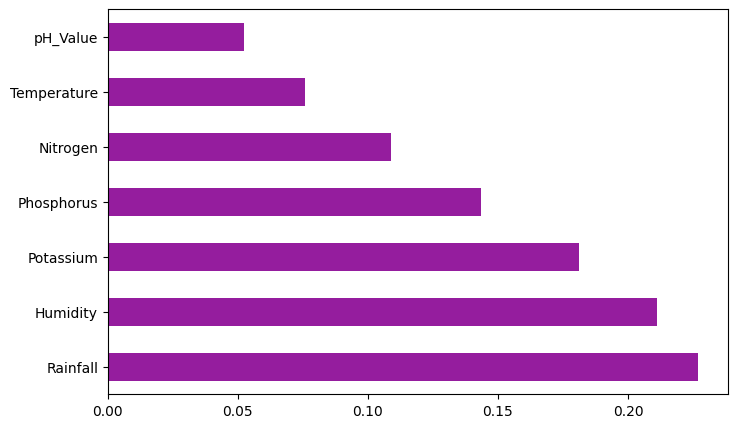

In [ ]:
feat_imp = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feat_imp.plot(
    kind='barh',
    color="#951D9E",
    figsize=(8, 5)
)
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
plt.figure(figsize=(12, 5))
df['Crop'].value_counts().plot(
    kind='bar',
    color='#1D9E75',
    edgecolor='black'
)
plt.title('Crop Distribution')
plt.xlabel('Crop')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

TypeError: 'module' object is not callable

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    df.corr(),
    annot=True,
    fmt='.2f',
    cmap='magma'
)
plt.title('Feature Correlation Heatmap')
plt.show()


TypeError: 'module' object is not callable

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(y_test, classes=list(range(22)))
plt.figure(figsize=(12, 8))

for i in range(22):
    actual = y_test_bin[:, i]
    probability = y_prob[:, i]
    
    fpr, tpr, _ = roc_curve(actual, probability)
    score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Crop {i} = {score:.2f}')
    # for Baseline
plt.plot([0, 1], [0, 1], 
         color='black', 
         linestyle='--', 
         label='Baseline')

# for Labels
plt.title('ROC Curve - All Crops')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

# for legends
plt.legend(bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

TypeError: 'module' object is not callable

In [ ]:
input_data = [[90, 60, 43, 20.8, 82.0, 6.5, 39]]
input_scaled = scaler.transform(input_data)
result = model.predict(input_scaled)
print("Recommended Crop:", result[0])
print(le.inverse_transform(result))

Recommended Crop: 21
['Watermelon']


c:\Users\PMLS\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
# Pehle yeh check karo
import matplotlib.pyplot as plt
print(type(plt))

<class 'module'>
